# AAM Loader Playground

Interactive notebook for exploring the `src.data.load_data` utilities on the `tinyAAM` dataset.

Each section below focuses on one part of the data-loading pipeline:
- finding the available tracks on disk
- reading the AAM annotation files into pandas tables
- loading one audio track and converting it into chroma features
- aligning chord annotations to feature frames so the result is ready for model training

## Setup

This cell makes sure the repository root is on `sys.path`.

That matters because notebooks often run with `notebooks/` as the current working directory, while the loader code lives under `src/`.

In [1]:
from pathlib import Path
import sys

# Start from the notebook's current working directory.
repo_root = Path.cwd()
# If Jupyter launched inside notebooks/, move up to the repo root so imports work.
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

# Make the repository importable so `from src...` works in the notebook.
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

repo_root

PosixPath('/home/eca4zm/school/ml3/automatic-chord-recognition')

In [3]:
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Import the high-level dataset wrapper and the lower-level helpers.
from src.data import (
    AAMDataset,
    beat_annotations_to_intervals,
    extract_chroma_features,
    frame_labels_from_intervals,
    frame_times,
    load_training_example,
)
from src.features import (
    build_label_set,
    encode_chord_labels,
    preprocess_dataset,
    preprocess_track,
    simplify_chord_label,
    simplify_chord_sequence,
    stack_frame_dataset,
)

## Index the dataset

Create an `AAMDataset` object that points at your local `tinyAAM` folder.

The `list_tracks()` call builds a small summary table showing which track ids are available and where their mix audio and annotation files live.

In [4]:
# Point the dataset wrapper at your local tinyAAM folder.
dataset = AAMDataset(repo_root / "data/raw/tinyAAM")
# Build a summary table of the tracks currently available on disk.
tracks = dataset.list_tracks()
print(f"Found {len(tracks)} tracks")
tracks.head()

Found 20 tracks


,track_id,mix_audio,num_stems,beatinfo,onsets,segments
0,0001,/home/eca4zm/school/ml3/automatic-chord-recogn...,5,/home/eca4zm/school/ml3/automatic-chord-recogn...,/home/eca4zm/school/ml3/automatic-chord-recogn...,/home/eca4zm/school/ml3/automatic-chord-recogn...
1,0080,/home/eca4zm/school/ml3/automatic-chord-recogn...,4,/home/eca4zm/school/ml3/automatic-chord-recogn...,/home/eca4zm/school/ml3/automatic-chord-recogn...,/home/eca4zm/school/ml3/automatic-chord-recogn...
2,0192,/home/eca4zm/school/ml3/automatic-chord-recogn...,5,/home/eca4zm/school/ml3/automatic-chord-recogn...,/home/eca4zm/school/ml3/automatic-chord-recogn...,/home/eca4zm/school/ml3/automatic-chord-recogn...
3,0620,/home/eca4zm/school/ml3/automatic-chord-recogn...,6,/home/eca4zm/school/ml3/automatic-chord-recogn...,/home/eca4zm/school/ml3/automatic-chord-recogn...,/home/eca4zm/school/ml3/automatic-chord-recogn...
4,0758,/home/eca4zm/school/ml3/automatic-chord-recogn...,7,/home/eca4zm/school/ml3/automatic-chord-recogn...,/home/eca4zm/school/ml3/automatic-chord-recogn...,/home/eca4zm/school/ml3/automatic-chord-recogn...


In [5]:
# Pick a track id to inspect. Change this to try another song.
track_id = "0001"
# Load the three annotation tables for this track.
annotations = dataset.load_annotations(track_id)

print("beatinfo")
# beatinfo stores beat-level chord labels.
display(annotations["beatinfo"].head())

print("segments")
# segments stores larger structural regions and keys.
display(annotations["segments"].head())

beatinfo


,Start time in seconds,Bar count,Quarter count,Chord name
0,0.000000,1,1,Fmaj
1,0.652174,1,2,Fmaj
2,1.304348,1,3,Fmaj
3,1.956522,1,4,Fmaj
4,2.608696,2,1,A#maj


segments


,Start time in seconds,Mark,Tempo,Key,Instruments,Generator
0,0.000000,A,92.0,Fmaj,"[TenorSax,Ukulele,OrganBass]","[MelodyBow,ChordArpeggios,BassLine]"
1,15.652174,A,92.0,Fmaj,"[TenorSax,Ukulele,OrganBass]","[MelodyBow,ChordArpeggios,BassLine]"
2,31.304348,A,92.0,Fmaj,"[TenorSax,Ukulele,OrganBass]","[MelodyBow,ChordArpeggios,BassLine]"
3,46.956520,A,92.0,Fmaj,"[TenorSax,Ukulele,OrganBass]","[MelodyBow,ChordArpeggios,BassLine]"
4,62.608696,A,92.0,Fmaj,"[TenorSax,Ukulele,OrganBass]","[MelodyBow,ChordArpeggios,BassLine]"


This section is useful for checking that the parser is reading the AAM annotations correctly.

- `beatinfo` contains beat-level chord labels.
- `segments` contains larger structural sections and their keys.

If you want to inspect another song, just change `track_id` above.

## Load one training example

`load_training_example(...)` is the highest-level helper in `load_data.py`.

It performs the most common pipeline for training:
- load the mix audio
- compute chroma features
- compute a timestamp for each frame
- align the chord annotations to those frame timestamps

In [6]:
# Run the full preprocessing path for one training example.
example = load_training_example(track_id, root=repo_root / "data/raw/tinyAAM")

print("audio shape:", example["audio"].shape)
print("sample rate:", example["sample_rate"])
print("chroma shape:", example["chroma"].shape)
print("frame labels shape:", example["frame_labels"].shape)
print("first 20 labels:", example["frame_labels"][:20].tolist())

audio shape: (2705997,)
sample rate: 22050
chroma shape: (12, 5286)
frame labels shape: (5286,)
first 20 labels: ['Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj']


In [7]:
# Count how often each chord label appears in the aligned frame labels.
unique_labels = pd.Series(example["frame_labels"]).value_counts()
unique_labels.head(15)

Fmaj     1294
Dmin     1123
Gmin      791
A#maj     729
Cmaj      561
D#maj     394
Amin      282
Cmin      112
Name: count, dtype: int64

This quick count shows which chord labels appear most often in the chosen track.

That is a simple sanity check that your label alignment is producing realistic chord names instead of empty strings or parsing artifacts.

## Plot the chroma features

This plot shows the chroma matrix that would typically be fed into a chord-recognition model.

The rows correspond to pitch classes and the columns correspond to time frames.

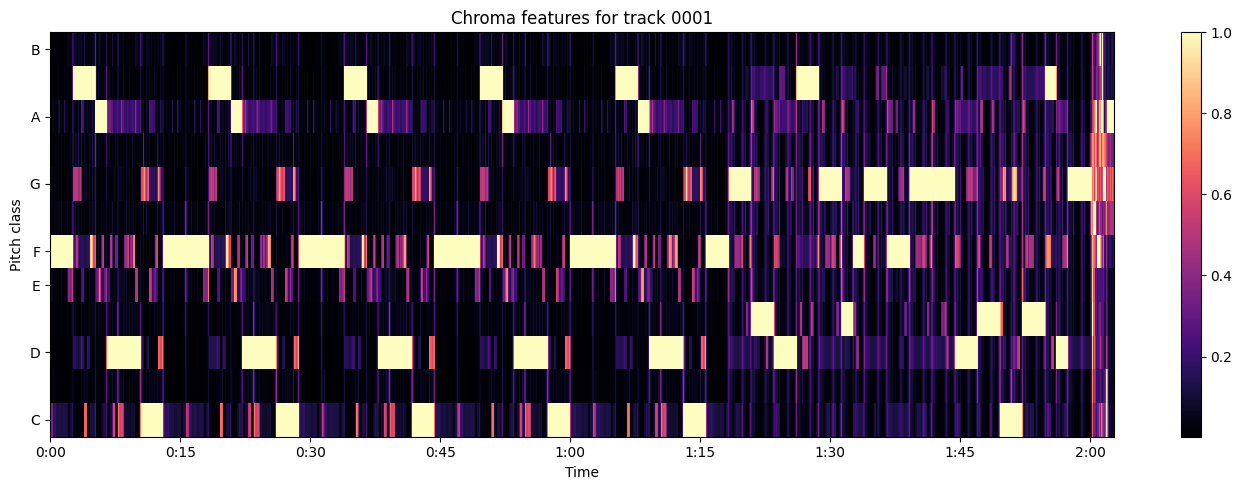

In [8]:
# Visualize the chroma representation over time.
plt.figure(figsize=(14, 5))
librosa.display.specshow(
    example["chroma"],
    x_axis="time",
    y_axis="chroma",
    sr=example["sample_rate"],
    hop_length=512,
)
plt.colorbar()
plt.title(f"Chroma features for track {track_id}")
plt.tight_layout()
plt.show()

## Inspect frame labels against beat annotations

The next two cells make the time alignment more transparent.

First we convert beatwise chord annotations into explicit time intervals, then we inspect the first few frame timestamps and the labels assigned to them.

In [9]:
# Convert beat timestamps into explicit [start, end) chord intervals.
intervals = beat_annotations_to_intervals(
    example["beatinfo"],
    audio_duration=len(example["audio"]) / example["sample_rate"],
)
intervals.head(12)

,start,chord,end
0,0.000000,Fmaj,0.652174
1,0.652174,Fmaj,1.304348
2,1.304348,Fmaj,1.956522
3,1.956522,Fmaj,2.608696
4,2.608696,A#maj,3.260870
5,3.260870,A#maj,3.913044
6,3.913044,A#maj,4.565218
7,4.565218,A#maj,5.217391
8,5.217391,Amin,5.869566
9,5.869566,Amin,6.521739


In [11]:
# Show the first few frame timestamps and the chord label assigned to each one.
preview = pd.DataFrame(
    {
        "time": example["frame_times"][:40],
        "label": example["frame_labels"][:40],
    }
)
preview.head(20)

,time,label
0,0.000000,Fmaj
1,0.023220,Fmaj
2,0.046440,Fmaj
3,0.069660,Fmaj
4,0.092880,Fmaj
5,0.116100,Fmaj
6,0.139320,Fmaj
7,0.162540,Fmaj
8,0.185760,Fmaj
9,0.208980,Fmaj


## Manual step-by-step version

Use this section if you want to swap parameters without calling `load_training_example`.

This is the best place to experiment with things like:
- a different `hop_length`
- loading a different `track_id`
- trying a different feature function later on

It mirrors the higher-level helper, but exposes each intermediate result directly.

In [12]:
# Load the raw mix audio at a fixed sample rate.
audio, sr = dataset.load_audio(track_id, source="mix", sr=22050, mono=True)
# Pull just the beatwise chord annotations for manual alignment.
beatinfo = dataset.load_annotations(track_id)["beatinfo"]

# Larger hop_length means fewer time frames and coarser time resolution.
hop_length = 1024
# Compute chroma features from the raw waveform.
chroma = extract_chroma_features(audio, sr, hop_length=hop_length)
# Compute the timestamp of each chroma frame.
times = frame_times(chroma.shape[1], sr, hop_length=hop_length)
# Convert beat annotations into chord intervals spanning time.
intervals = beat_annotations_to_intervals(beatinfo, audio_duration=len(audio) / sr)
# Assign a chord label to every feature frame.
labels = frame_labels_from_intervals(intervals, times)

print("manual chroma shape:", chroma.shape)
print("manual labels shape:", labels.shape)
print("manual label sample:", labels[:20].tolist())

manual chroma shape: (12, 2643)
manual labels shape: (2643,)
manual label sample: ['Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj', 'Fmaj']


## Preprocessing sandbox

These cells exercise the higher-level preprocessing helpers in `src.features`.

The goal here is to move from raw string labels and per-track features into a small, model-ready dataset with integer targets.

In [ ]:
# Example raw chord labels in a few different formats.
raw_labels = ["Fmaj", "Dmin", "Bb:maj7", "G:sus4", "", None]
# Reduce the labels to the simpler major/minor/no-chord vocabulary.
simplified_labels = simplify_chord_sequence(raw_labels)
pd.DataFrame({"raw": raw_labels, "simplified": simplified_labels})

In [ ]:
# Build the fixed label vocabulary used for encoding targets.
label_set = build_label_set()
# Preprocess one track into features plus string and integer labels.
preprocessed_track = preprocess_track(
    track_id,
    root=repo_root / "data/raw/tinyAAM",
    sr=22050,
    hop_length=512,
    label_set=label_set,
)

print("feature shape:", preprocessed_track.features.shape)
print("encoded label shape:", preprocessed_track.encoded_labels.shape)
print("first 20 chord labels:", preprocessed_track.chord_labels[:20].tolist())
print("first 20 encoded labels:", preprocessed_track.encoded_labels[:20].tolist())

In [ ]:
# Show exactly how string chord labels map into integer class ids.
label_preview = preprocessed_track.chord_labels[:12]
encoded_preview = encode_chord_labels(label_preview, label_set=label_set)
pd.DataFrame({"label": label_preview, "encoded": encoded_preview})

In [ ]:
# Preprocess a few tracks together to simulate a small trainable dataset.
small_dataset = preprocess_dataset(
    root=repo_root / "data/raw/tinyAAM",
    track_ids=["0001", "0080", "0192"],
    sr=22050,
    hop_length=512,
    label_set=label_set,
)
# The metadata table summarizes the size of each preprocessed track.
small_dataset["metadata"]

In [ ]:
# Stack the per-track examples into one framewise matrix for a baseline classifier.
X, y = stack_frame_dataset(small_dataset["tracks"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("first 10 targets:", y[:10].tolist())